In [1]:
import fastf1 as ff1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utility import set_dark

# local cache to avoid repeated downloads
ff1.Cache.enable_cache('./data/cache')

# Focusing on Max Verstappen

### Analyzing Max Verstappen's Qualifying pace
Max Verstappen Eliminated in Q1 on Pure Pace (not due to accidents) For the First Time in his Career!

Let's analyze his qualifying pace in Q1 and the car setup compared to others. 

In [2]:
session_q = ff1.get_session(2025, 'Brazil', 'Q')

session_q.load()

core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INF

In [93]:
drivers = [
    "NOR",
    "VER",
    "PIA",
    "RUS",
    "LEC",
    "HAM",
    "ANT",
    "ALB",
    "HUL",
    "SAI",
    "ALO",
    "STR",
    "OCO",
    "TSU",
    "GAS",
    "HAD",
    "BOR",
    "LAW",
    "BEA",
    "COL"
]
laps = session_q.laps.pick_not_deleted()
q1, q2, q3 = laps.split_qualifying_sessions()


# Only care Q1
# sector 1

# https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#copy-on-write 
pd.options.mode.copy_on_write = True 

def sector_time(q, sector:str ='Sector1Time') -> pd.DataFrame:
    sector_data = {
        'Driver': [],
        sector: [], 
        'Color': []
    }
    for driver in drivers:
        driver_laps = q.pick_drivers(driver)
            
        # laps.pick_fastest() => pd.Series
        best_lap = driver_laps.pick_fastest()
        if best_lap is None: continue
        
        best_lap[sector] = pd.to_timedelta(best_lap[sector])
        s1 = best_lap[sector].total_seconds()
        # s2 = best_lap['Sector2Time'].dt.total_seconds()
        # s3 = best_lap['Sector3Time'].dt.total_seconds()
        
        sector_data['Driver'].append(driver)
        sector_data[sector].append(s1)
        
        color = ff1.plotting.get_driver_color(driver, session_q)
        sector_data['Color'].append(color)

    sector_total = pd.DataFrame(sector_data)
    return sector_total

sector1 = sector_time(q1, 'Sector1Time')
sector2 = sector_time(q1, 'Sector2Time')
sector3 = sector_time(q1, 'Sector3Time')

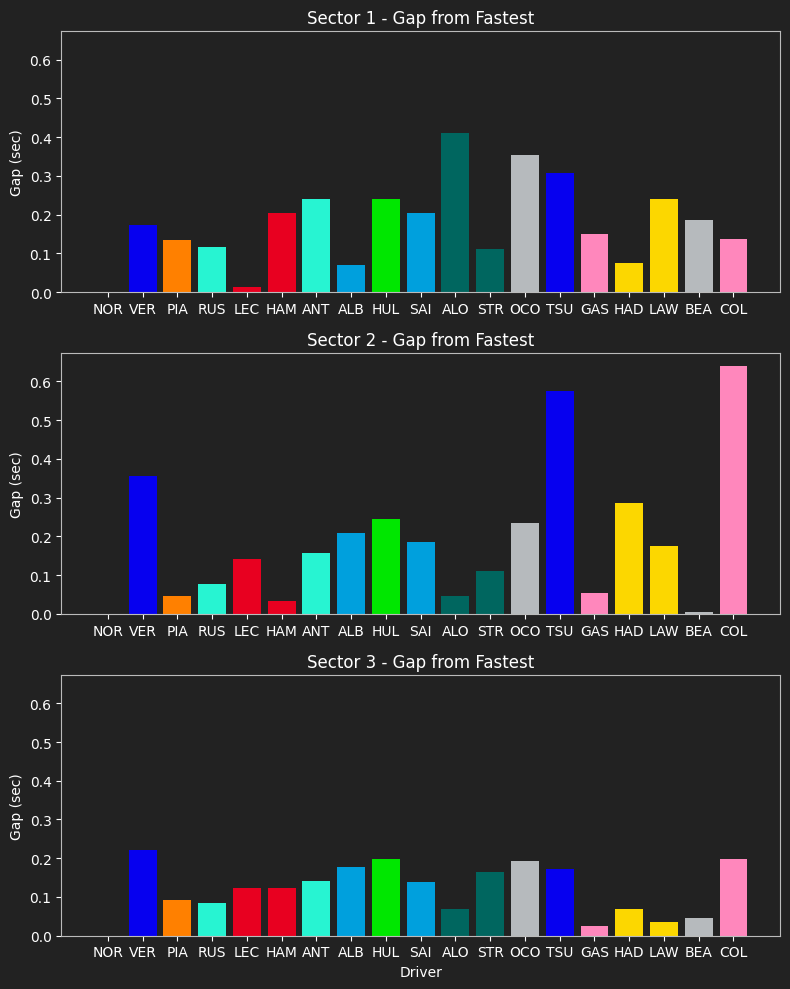

In [ ]:
# consistent scale was needed for the three graphs
# get the maximum gap in sector1, sector2, sector3
sector1_gap = sector1.copy()
sector1_gap['Gap'] = sector1_gap['Sector1Time'] - sector1_gap['Sector1Time'].min()

sector2_gap = sector2.copy()
sector2_gap['Gap'] = sector2_gap['Sector2Time'] - sector2_gap['Sector2Time'].min()

sector3_gap = sector3.copy()
sector3_gap['Gap'] = sector3_gap['Sector3Time'] - sector3_gap['Sector3Time'].min()

max_gap = max(sector1_gap['Gap'].max(), sector2_gap['Gap'].max(), sector3_gap['Gap'].max())
# add margin
y_max = max_gap * 1.05

# vizualization 
fig, ax = plt.subplots(3, 1, figsize=(8, 10))
set_dark(ax[0])
set_dark(ax[1])
set_dark(ax[2])

# or use sns.barplot(data=sector1_gap, x=, y=, ax=ax[0], ...)
ax[0].bar(sector1_gap['Driver'], sector1_gap['Gap'], color=sector1_gap['Color'])
ax[0].set_ylim(0, y_max)
ax[0].set_title('Sector 1 - Gap from Fastest')
ax[0].set_ylabel('Gap (sec)')

ax[1].bar(sector2_gap['Driver'], sector2_gap['Gap'], color=sector1_gap['Color'])
ax[1].set_ylim(0, y_max)
ax[1].set_title('Sector 2 - Gap from Fastest')
ax[1].set_ylabel('Gap (sec)')

ax[2].bar(sector3_gap['Driver'], sector3_gap['Gap'], color=sector1_gap['Color'])
ax[2].set_ylim(0, y_max)
ax[2].set_title('Sector 3 - Gap from Fastest')
ax[2].set_ylabel('Gap (sec)')
ax[2].set_xlabel('Driver')

plt.tight_layout()
plt.show()

- __NOR__ was the fastest in all 3 sectors!
- Both Red Bulls:__VER__ and __TSU__ remarkably struggled compared to the others.   
It shows how slow Red Bull cars were compared to the other teams.
- __VER__ was behind __NOR__ more than 0.2 seconds per sector. 

### Verstappen After Car Upgrade  -> compare mean speed v. top speed, ... laptimes, ...